In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# ──────────────────────────────────────────
# OBJECTIVE FUNCTION (minimize this)
# ──────────────────────────────────────────

def objective_function(x):
    # Simple function: f(x) = x^2 (minimum at x=0)
    return x[0]**2 + x[1]**2

def affinity(antibody):
    # Higher affinity = lower objective value
    return 1 / (1 + objective_function(antibody))


In [5]:
# ──────────────────────────────────────────
# PARAMETERS
# ──────────────────────────────────────────

POP_SIZE = 20          # number of antibodies
NUM_CLONES = 5         # clones per antibody
MUTATION_RATE = 0.1    # mutation strength
GENERATIONS = 50       # number of iterations
DIMENSIONS = 2         # problem dimensions

LOWER_BOUND = -5.0     # search space lower bound
UPPER_BOUND = 5.0      # search space upper bound

# ──────────────────────────────────────────
# STEP 1 - INITIALIZE POPULATION
# ──────────────────────────────────────────

def initialize_population():
    return np.random.uniform(LOWER_BOUND, UPPER_BOUND,
                             (POP_SIZE, DIMENSIONS))

# ──────────────────────────────────────────
# STEP 2 - CLONAL EXPANSION
# ──────────────────────────────────────────

def clonal_expansion(population):

    clones = []

    for antibody in population:
        for _ in range(NUM_CLONES):
            clones.append(antibody.copy())

    return np.array(clones)

# ──────────────────────────────────────────
# STEP 3 - MUTATION
# ──────────────────────────────────────────

def mutate(clones):

    mutated = []

    for clone in clones:

        mutation = np.random.uniform(
            -MUTATION_RATE,
            MUTATION_RATE,
            DIMENSIONS
        )

        new_clone = clone + mutation

        # keep within bounds
        new_clone = np.clip(
            new_clone,
            LOWER_BOUND,
            UPPER_BOUND
        )

        mutated.append(new_clone)

    return np.array(mutated)

# ──────────────────────────────────────────
# STEP 4 - SELECTION
# ──────────────────────────────────────────

def selection(population, clones):

    combined = np.vstack((population, clones))

    # sort by affinity (highest first)
    affinities = np.array([affinity(ab) for ab in combined])

    sorted_idx = np.argsort(affinities)[::-1]

    # keep top POP_SIZE antibodies
    selected = combined[sorted_idx[:POP_SIZE]]

    return selected

 Clonal Selection Algorithm (CSA)
 Generation   1 | Best Value: 0.355230 | Best Solution: [0.51584994 0.29854524]
 Generation  11 | Best Value: 0.000050 | Best Solution: [-0.00675079 -0.00217749]
 Generation  21 | Best Value: 0.000009 | Best Solution: [-0.00283948  0.00074408]
 Generation  31 | Best Value: 0.000009 | Best Solution: [-0.00283948  0.00074408]
 Generation  41 | Best Value: 0.000005 | Best Solution: [-0.00206225  0.00082843]
 Generation  50 | Best Value: 0.000000 | Best Solution: [ 0.00039281 -0.00057478]

 FINAL RESULT:
 Best Solution : [ 0.00039281 -0.00057478]
 Best Value    : 0.000000


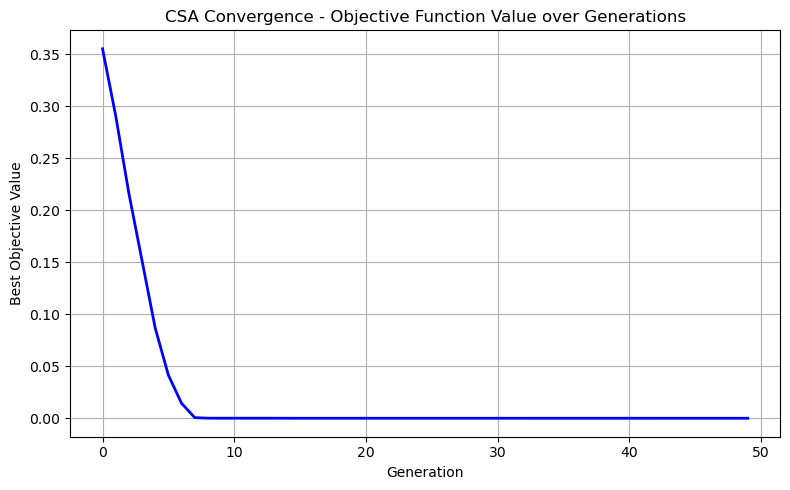

In [7]:
# ──────────────────────────────────────────
# MAIN - CLONAL SELECTION ALGORITHM
# ──────────────────────────────────────────

def clonal_selection_algorithm():

    population = initialize_population()

    best_fitness_history = []

    print("=" * 45)
    print(" Clonal Selection Algorithm (CSA)")
    print("=" * 45)

    for gen in range(GENERATIONS):

        # Clonal Expansion
        clones = clonal_expansion(population)

        # Mutation
        mutated_clones = mutate(clones)

        # Selection
        population = selection(population, mutated_clones)

        # Track best solution
        best = min(population,
                   key=lambda ab: objective_function(ab))

        best_val = objective_function(best)

        best_fitness_history.append(best_val)

        if gen % 10 == 0 or gen == GENERATIONS - 1:
            print(f" Generation {gen+1:3d} | "
                  f"Best Value: {best_val:.6f} | "
                  f"Best Solution: {best}")

    print("=" * 45)
    print(f"\n FINAL RESULT:")
    print(f" Best Solution : {best}")
    print(f" Best Value    : {best_val:.6f}")
    print("=" * 45)

    return best_fitness_history

# ──────────────────────────────────────────
# RUN AND PLOT
# ──────────────────────────────────────────

if __name__ == "__main__":

    history = clonal_selection_algorithm()

    # Plot convergence
    plt.figure(figsize=(8, 5))

    plt.plot(history, color='blue', linewidth=2)

    plt.title("CSA Convergence - Objective Function Value over Generations")

    plt.xlabel("Generation")
    plt.ylabel("Best Objective Value")

    plt.grid(True)
    plt.tight_layout()

    plt.show()